# Влияние correlation length

В этом ноутбуке исследуется влияние пространственного масштаба неоднородностей материала на развитие пробоя.

Параметр `correlation_length` определяет характерный размер областей повышенной и пониженной электрической прочности.

Для каждого значения `correlation_length` используются одинаковые наборы `disorder_seed` и `random_seed`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SimulationConfig
from src.analysis_utils import (
    run_parameter_sweep,
    build_material_summary,
    build_bootstrap_summary,
)

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    weibull_shape=5.0,
    mean_breakdown_field=3.0,
    max_growth_steps=5000,
)

In [3]:
correlation_lengths = [1, 3, 5, 10, 15]

disorder_seeds = range(20)
random_seeds = range(10)

In [4]:
results_df = run_parameter_sweep(
    base_config=base_config,
    parameter_name="correlation_length",
    parameter_values=correlation_lengths,
    disorder_seeds=disorder_seeds,
    random_seeds=random_seeds,
)

In [5]:
print(results_df.shape)

results_df.groupby(
    "correlation_length"
).size()

results_df.to_csv(
    "correlation_length_results.csv",
    index=False,
)

(1000, 9)


In [6]:
material_summary = build_material_summary(
    results_df,
    parameter_name="correlation_length",
)

material_summary.head()

,correlation_length,disorder_seed,n_started,n_breakdown,p_start,p_breakdown,mean_steps,mean_height,p_breakdown_given_start
0,1,0,10,0,1.0,0.0,5.7,0.125984,0.0
1,1,1,0,0,0.0,0.0,0.0,0.000000,NaN
2,1,2,10,10,1.0,1.0,332.8,1.000000,1.0
3,1,3,10,0,1.0,0.0,3.0,0.125984,0.0
4,1,4,10,0,1.0,0.0,3.0,0.110236,0.0


In [7]:
stats = build_bootstrap_summary(
    material_summary,
    parameter_name="correlation_length",
    parameter_values=correlation_lengths,
    n_random=len(random_seeds),
)

stats

,p_start,p_start_low,p_start_high,p_breakdown,p_breakdown_low,p_breakdown_high,p_breakdown_given_start,conditional_low,conditional_high,correlation_length
0,0.65253,0.45,0.85,0.161631,0.025000,0.320125,0.247517,0.045455,0.486687,1
1,0.59986,0.40,0.80,0.534459,0.304875,0.750000,0.890909,0.700000,1.000000,3
2,0.59659,0.40,0.80,0.546310,0.300000,0.750000,0.915724,0.727273,1.000000,5
3,0.45017,0.25,0.65,0.450170,0.250000,0.650000,1.000000,1.000000,1.000000,10
4,0.59923,0.40,0.80,0.599230,0.400000,0.800000,1.000000,1.000000,1.000000,15


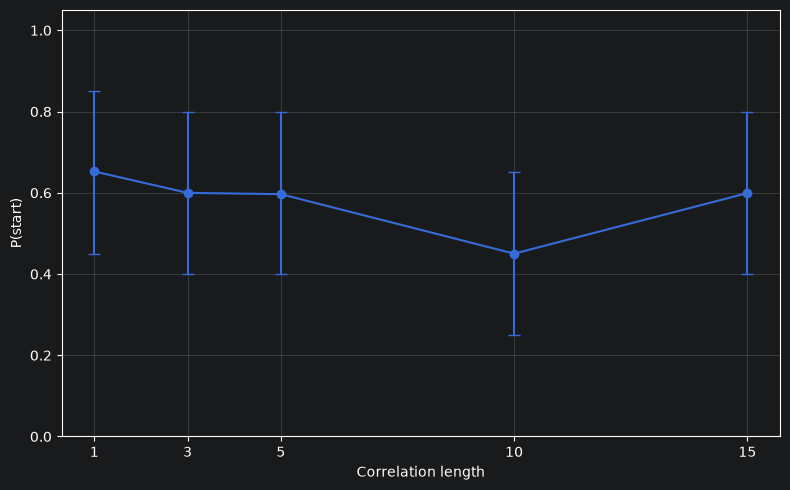

In [8]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_start"] - stats["p_start_low"],
    stats["p_start_high"] - stats["p_start"],
])

plt.errorbar(
    stats["correlation_length"],
    stats["p_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Correlation length")
plt.ylabel("P(start)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

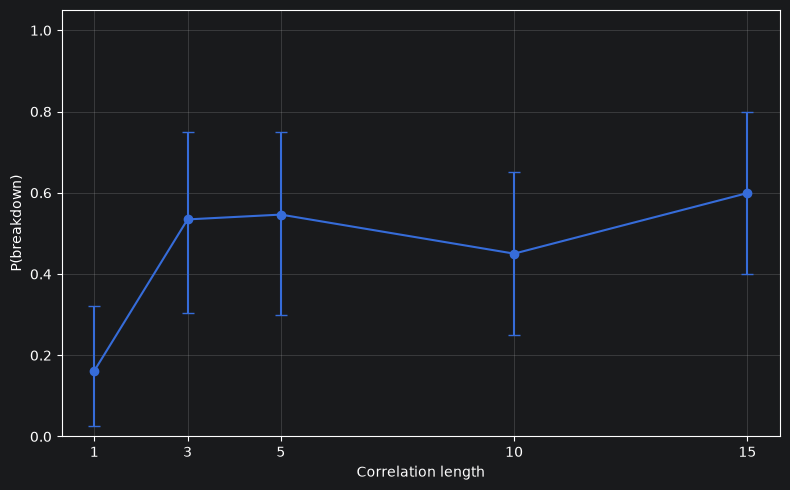

In [9]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown"] - stats["p_breakdown_low"],
    stats["p_breakdown_high"] - stats["p_breakdown"],
])

plt.errorbar(
    stats["correlation_length"],
    stats["p_breakdown"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Correlation length")
plt.ylabel("P(breakdown)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

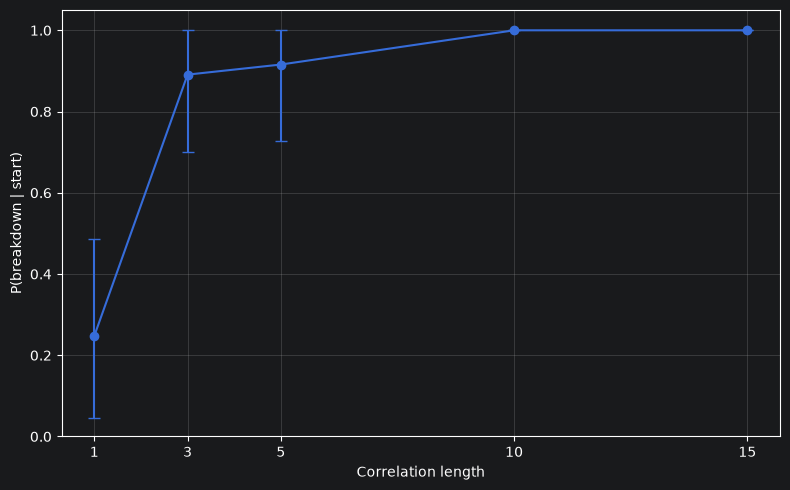

In [10]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown_given_start"] - stats["conditional_low"],
    stats["conditional_high"] - stats["p_breakdown_given_start"],
])

plt.errorbar(
    stats["correlation_length"],
    stats["p_breakdown_given_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Correlation length")
plt.ylabel("P(breakdown | start)")
plt.xticks(correlation_lengths)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
from scipy.stats import friedmanchisquare

pivot_start = material_summary.pivot(
    index="disorder_seed",
    columns="correlation_length",
    values="p_start",
)

stat, p_value = friedmanchisquare(
    *[
        pivot_start[xi].values
        for xi in correlation_lengths
    ]
)

print("Friedman statistic:", stat)
print("p-value:", p_value)

Friedman statistic: 2.9677419354839594
p-value: 0.5632381433159706


### Влияние correlation length на старт

Критерий Фридмана не выявил статистически значимого влияния `correlation_length` на вероятность старта канала:

$$
\chi_F^2 \approx 2.97,
$$

$$
p \approx 0.56.
$$

Таким образом, изменение пространственного масштаба неоднородностей в рассматриваемом диапазоне не оказывает заметного влияния на сам факт старта пробоя.

In [12]:
material_summary.groupby("correlation_length")[
    "p_breakdown_given_start"
].count()

pivot_conditional = material_summary.pivot(
    index="disorder_seed",
    columns="correlation_length",
    values="p_breakdown_given_start",
)

complete_conditional = pivot_conditional.dropna()

print("Complete materials:", len(complete_conditional))

complete_conditional

Complete materials: 5


correlation_length,1,3,5,10,15
disorder_seed,,,,,
0,0.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0
5,0.9,1.0,1.0,1.0,1.0
13,0.0,1.0,1.0,1.0,1.0
15,0.0,1.0,1.0,1.0,1.0


### Вывод

Изменение `correlation_length` в исследованном диапазоне не показало статистически значимого влияния на вероятность старта пробоя:

$$
p \approx 0.56.
$$

При этом наблюдается сильное влияние на дальнейшее распространение канала: при малом `correlation_length` стартовавший канал часто останавливается, тогда как при больших значениях параметра вероятность полного пробоя после старта приближается к единице.

Таким образом, `correlation_length` в большей степени определяет устойчивость дальнейшего роста канала, чем сам факт его возникновения.

Этот параметр следует включить в будущий датасет как отдельный физически значимый признак.